In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [28]:
df = pd.read_csv(r'C:\Users\Linh\Desktop\Growth & Experimentation Project for Ride-Hailing Promotions\02. Synthetic_data\outputs\customer_features_final.csv')
df

,user_id,age,gender,home_borough,total_rides,recency_days,typical_distance,route_entropy,pct_airport,pref_time_bucket,weekend_ratio,pct_flex_payment,resid_tip_rate,avg_fare
0,1,57,Female,Manhattan,10,41,4.810,-0.000000,0.000000,morning,0.000000,0.000000,-0.136444,22.600
1,2,47,Female,Manhattan,6,34,4.196,1.054920,0.454545,evening,0.000000,0.000000,0.027773,17.179
2,3,26,Female,Manhattan,6,81,2.790,1.722419,0.000000,midday,0.153846,0.000000,0.034695,19.567
3,4,35,Female,Manhattan,11,15,3.690,1.672625,0.000000,morning,0.000000,0.083333,0.037278,40.980
4,5,39,Male,Manhattan,3,39,0.600,1.286057,0.000000,midday,0.285714,0.000000,-0.111906,8.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,34,Other,Manhattan,4,80,0.840,1.213008,0.000000,midday,0.000000,0.000000,0.033269,7.300
19996,19997,65,Other,Manhattan,21,57,6.248,0.950271,0.142857,morning,0.000000,0.000000,-0.222520,26.211
19997,19998,62,Male,Manhattan,6,38,2.100,1.494175,0.200000,midday,0.500000,0.000000,0.028315,12.300
19998,19999,31,Other,Brooklyn,6,11,0.600,1.332179,0.000000,midday,0.000000,0.000000,-0.027678,8.367


In [29]:
df.shape

(20000, 14)

In [30]:
df.isnull().sum()

user_id             0
age                 0
gender              0
home_borough        0
total_rides         0
recency_days        0
typical_distance    0
route_entropy       0
pct_airport         0
pref_time_bucket    0
weekend_ratio       0
pct_flex_payment    0
resid_tip_rate      0
avg_fare            0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df['user_id'].duplicated().sum()

np.int64(0)

In [33]:
df['recency_days'].describe()

count    20000.000000
mean        55.750300
std         53.956029
min          0.000000
25%         16.000000
50%         38.000000
75%         79.000000
max        277.000000
Name: recency_days, dtype: float64

In [34]:
df['typical_distance'].describe()

count    20000.000000
mean         3.125130
std          3.438656
min          0.010000
25%          1.170000
50%          1.920000
75%          3.520000
max         44.330000
Name: typical_distance, dtype: float64

In [35]:
df['weekend_ratio'].describe()

count    20000.000000
mean         0.286697
std          0.296805
min          0.000000
25%          0.000000
50%          0.222222
75%          0.500000
max          1.000000
Name: weekend_ratio, dtype: float64

In [36]:
df['resid_tip_rate'].describe()

count    20000.000000
mean         0.003272
std          0.094569
min         -0.343509
25%         -0.032643
50%          0.018967
75%          0.047834
max          0.687170
Name: resid_tip_rate, dtype: float64

# Chuẩn hoá

In [37]:
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES = ["route_entropy", "resid_tip_rate", "pct_flex_payment",
                    "pct_airport", "total_rides", "weekend_ratio"]


X = StandardScaler().fit_transform(df[CLUSTER_FEATURES].to_numpy(dtype=float))
print("Ma tran cluster:", X.shape)
print("mean ~ 0:", np.abs(X.mean(0)).max().round(6), " | std ~ 1:", X.std(0).round(4))

Ma tran cluster: (20000, 6)
mean ~ 0: 0.0  | std ~ 1: [1. 1. 1. 1. 1. 1.]


# Chọn K

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42

def null_matrix(X, seed=0):
    rng = np.random.default_rng(seed)
    return np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])

def choose_k(X, k_range=range(2, 9), seed=SEED, sil_n=8000):
    rng = np.random.default_rng(0)
    sub = rng.choice(len(X), min(sil_n, len(X)), replace=False)
    Xn  = null_matrix(X, seed)
    rows = []
    for k in k_range:
        km = KMeans(k, n_init=10, random_state=seed).fit(X)
        kn = KMeans(k, n_init=10, random_state=seed).fit(Xn)
        a  = KMeans(k, n_init=10, random_state=seed + 1).fit_predict(X)
        b  = KMeans(k, n_init=10, random_state=seed + 2).fit_predict(X)
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X[sub], km.labels_[sub]),
            "silhouette_null": silhouette_score(Xn[sub], kn.labels_[sub]),
            "inertia": km.inertia_,
            "ari_2_seed": adjusted_rand_score(a, b),
            "min_share": pd.Series(km.labels_).value_counts(normalize=True).min(),
        })
    t = pd.DataFrame(rows)
    t["sil_gap"] = t.silhouette - t.silhouette_null
    return t

ktab = choose_k(X)
BEST_K = int(ktab.loc[ktab.sil_gap.idxmax(), "k"])
display(ktab.round(4))
print(f"K duoc chon = {BEST_K}")

,k,silhouette,silhouette_null,inertia,ari_2_seed,min_share,sil_gap
0,2,0.2050,0.2222,98935.3883,0.9964,0.2524,-0.0172
1,3,0.2469,0.2361,81479.0016,1.0000,0.1925,0.0108
2,4,0.2634,0.1932,68379.3339,0.9978,0.0972,0.0701
3,5,0.2625,0.1976,60182.5541,0.9982,0.0915,0.0649
4,6,0.2489,0.2025,54491.0284,0.9471,0.0868,0.0464
5,7,0.2355,0.2046,50293.3413,0.9732,0.0711,0.0309
6,8,0.2361,0.1733,47038.5546,0.9973,0.0606,0.0629


K duoc chon = 4


In [39]:
SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES, ALT     = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"

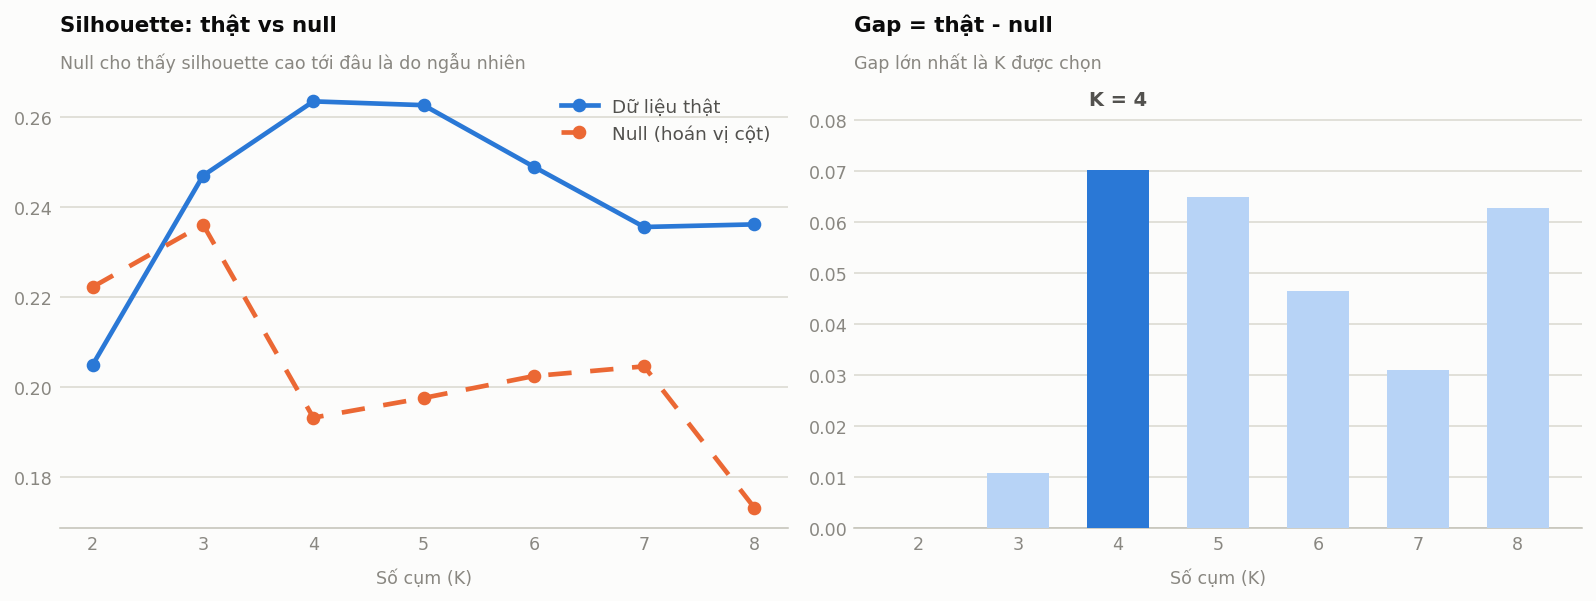

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), dpi=140)
fig.patch.set_facecolor(SURFACE)

ax = axes[0]; ax.set_facecolor(SURFACE)
ax.plot(ktab.k, ktab.silhouette, color=SERIES, lw=2.4, marker="o", ms=6,
        zorder=4, label="Dữ liệu thật")
ax.plot(ktab.k, ktab.silhouette_null, color=ALT, lw=2.4, marker="o", ms=6,
        ls=(0, (5, 4)), zorder=4, label="Null (hoán vị cột)")
ax.set_title("Silhouette: thật vs null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Null cho thấy silhouette cao tới đâu là do ngẫu nhiên",
        transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")
leg = ax.legend(frameon=False, fontsize=9.5, loc="upper right")
for t in leg.get_texts(): t.set_color(SECOND)

ax = axes[1]; ax.set_facecolor(SURFACE)
bars = ax.bar(ktab.k, ktab.sil_gap, color=[SERIES if k == BEST_K else "#b7d3f6"
                                           for k in ktab.k], width=0.62, zorder=3)
ax.text(BEST_K, ktab.sil_gap.max() + 0.012, f"K = {BEST_K}", ha="center",
        va="bottom", color=SECOND, fontsize=10, fontweight="bold")
ax.set_title("Gap = thật - null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Gap lớn nhất là K được chọn", transform=ax.transAxes,
        color=MUTED, fontsize=9, va="bottom")
ax.set_ylim(0, ktab.sil_gap.max() * 1.25)

for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(False)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    ax.set_xlabel("Số cụm (K)", color=MUTED, fontsize=9, labelpad=8)
    ax.set_xticks(ktab.k)

plt.tight_layout(); plt.show()

In [ ]:
# Dùng phương pháp Elbow
k_range = range(1, 10)

wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Diem gay = K 4


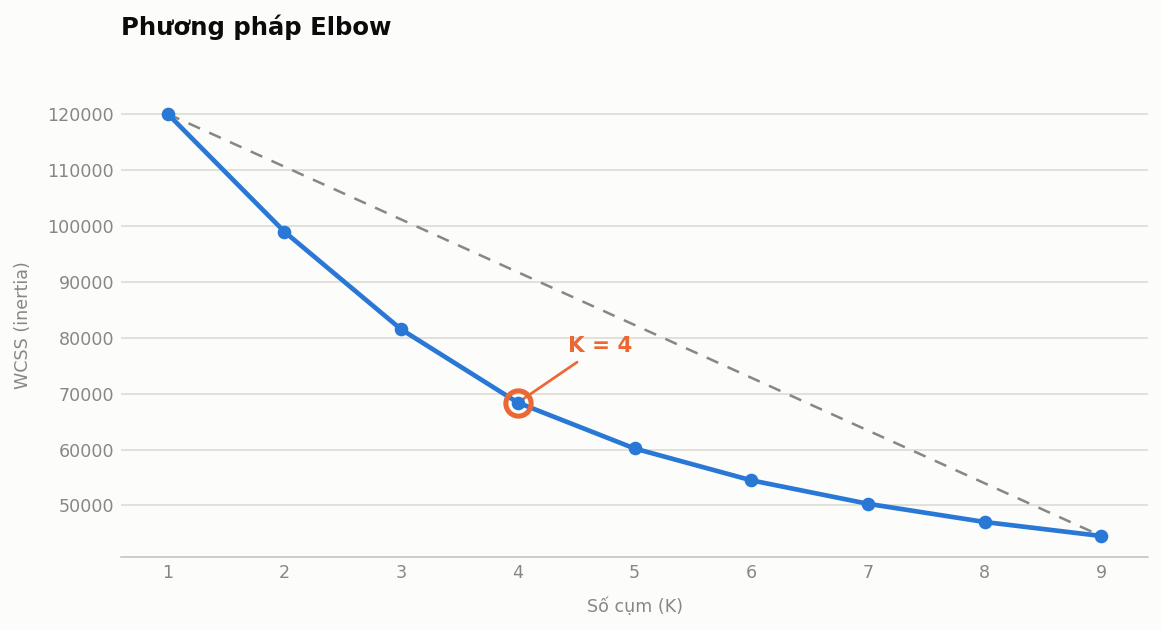

In [42]:
# Diem gay (knee): diem xa nhat so voi duong thang noi hai dau mut cua duong cong
kk = np.array(list(k_range)); yy = np.array(wcss)
kn = (kk - kk[0]) / (kk[-1] - kk[0])
yn = (yy - yy.min()) / (yy.max() - yy.min())
KNEE = int(kk[(np.abs(yn - (1 - kn)) / np.sqrt(2)).argmax()])

print(f"Diem gay = K {KNEE}")

fig, ax = plt.subplots(figsize=(8.4, 4.6), dpi=140)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

# duong noi hai dau mut — cai ma "diem gay" do khoang cach toi
ax.plot([kk[0], kk[-1]], [yy[0], yy[-1]], color=MUTED, lw=1.3,
        ls=(0, (5, 4)), zorder=2)
ax.plot(kk, yy, color=SERIES, lw=2.4, marker="o", ms=6, zorder=4)
ax.plot([KNEE], [yy[list(kk).index(KNEE)]], marker="o", ms=13, mfc="none",
        mec=ALT, mew=2.6, zorder=5)

yk = yy[list(kk).index(KNEE)]
ax.annotate(f"K = {KNEE}", xy=(KNEE, yk), xytext=(26, 26),
            textcoords="offset points", color=ALT, fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=ALT, lw=1.4))

ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(False)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=9)
ax.set_xticks(kk)
ax.set_xlabel("Số cụm (K)", color=MUTED, fontsize=9, labelpad=8)
ax.set_ylabel("WCSS (inertia)", color=MUTED, fontsize=9, labelpad=8)
ax.set_title("Phương pháp Elbow", color=INK, fontsize=12.5,
             fontweight="bold", loc="left", pad=30)

plt.tight_layout(); plt.show()

# KMeans

In [43]:
km = KMeans(BEST_K, n_init=10, random_state=SEED).fit(X)
df["cluster"] = km.labels_

size = (df.cluster.value_counts(normalize=True).sort_index() * 100).round(2)
print("Quy mo tung cum (%):"); print(size.to_string())

Quy mo tung cum (%):
cluster
0     9.72
1    49.43
2    22.56
3    18.29


# Lập hồ sơ persona

In [44]:
# Truc MO TA — khong vao KMeans, chi dung de lap ho so persona
PROFILE_FEATURES = ["typical_distance", "avg_fare", "weekend_ratio",
                    "pref_time_bucket", "home_borough"]

z = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
z["cluster"] = df.cluster

prof = z.groupby("cluster").mean().round(2)
prof.columns = [f"z_{c}" for c in prof.columns]
prof.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
prof.insert(0, "n", df.cluster.value_counts())

num = [c for c in PROFILE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
prof = prof.join(df.groupby("cluster")[num].mean().round(2))
prof = prof.join(df.groupby("cluster")[["total_rides"]].mean().round(2)
                 .rename(columns={"total_rides": "rides_TB"}))
display(prof.sort_index())

print("Khung gio troi cua tung cum (%):")
display((pd.crosstab(df.cluster, df.pref_time_bucket, normalize="index") * 100).round(1))

,n,share_%,z_route_entropy,z_resid_tip_rate,z_pct_flex_payment,z_pct_airport,z_total_rides,z_weekend_ratio,typical_distance,avg_fare,weekend_ratio,rides_TB
cluster,,,,,,,,,,,,
0,1943,9.72,0.11,0.73,-0.41,2.60,0.34,-0.02,8.97,41.39,0.28,9.68
1,9886,49.43,0.33,0.45,-0.38,-0.26,0.38,-0.05,2.10,17.03,0.27,9.88
2,4513,22.56,-0.87,-1.33,-0.53,-0.30,-0.78,-0.14,3.11,18.81,0.24,4.24
3,3658,18.29,0.12,0.04,1.90,-0.32,-0.24,0.32,2.81,23.52,0.38,6.84


Khung gio troi cua tung cum (%):


pref_time_bucket,evening,late_night,midday,morning
cluster,,,,
0,31.2,24.7,29.9,14.2
1,34.8,16.9,33.2,15.0
2,32.7,17.8,32.7,16.8
3,34.3,24.0,26.4,15.3


In [45]:
# Lưu data các cụm vào file
import os

OUTDIR = (r"c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing "
          r"Promotions/03. Segmentation/outputs")
os.makedirs(OUTDIR, exist_ok=True)

# Tu tinh ho so z-score o day thay vi dung bien `prof` cua cell 21, de cell nay
# chay duoc doc lap — khong phu thuoc vao viec da chay cell nao truoc do.
zp = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
zp["cluster"] = df.cluster
zprof = zp.groupby("cluster").mean().round(3)
zprof.columns = [f"z_{c}" for c in zprof.columns]

# Ten dat theo TRUC DAC TRUNG cua tung cum (xem phan dien giai ben duoi).
NAMES = {
    0: "Khach san bay / duong dai gia tri cao",
    1: "Khach do thi, di thuong xuyen",
    2: "Khach it gan ket, di theo lo trinh co dinh",
    3: "Khach cuoi tuan / giai tri",
}
TARGET_CLUSTER = 2      # nhom chon de A/B test

sig = {
    0: ("z_pct_airport",      "max"),   
    1: ("z_total_rides",      "max"),   
    2: ("z_resid_tip_rate",   "min"),   
    3: ("z_pct_flex_payment", "max"),   
}
for k, (axis, how) in sig.items():
    got = zprof[axis].idxmax() if how == "max" else zprof[axis].idxmin()
    assert got == k, (f"Cum {k} dang le co {axis} {how} nhung thuc te la cum {got}. "
                      f"Nhan cum da hoan vi — cap nhat lai NAMES truoc khi luu.")

# 1. Nhan cap rider — file ma buoc A/B testing se doc
rider = df[["user_id"]].copy()
rider["cluster"]   = df.cluster
rider["persona"]   = df.cluster.map(NAMES)
rider["is_target"] = (df.cluster == TARGET_CLUSTER).astype(int)
rider.to_csv(os.path.join(OUTDIR, "rider_cluster.csv"), index=False)

# 2. Ho so tung cum: z-score cac truc phan cum + vai chi so kinh doanh
out = zprof.copy()
out.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
out.insert(0, "n", df.cluster.value_counts())
out.insert(0, "persona", out.index.map(NAMES))
out = out.join(df.groupby("cluster")[["total_rides", "typical_distance",
                                      "avg_fare", "weekend_ratio"]].mean().round(2))
out.sort_index().to_csv(os.path.join(OUTDIR, "cluster_profiles.csv"))

# 3. Toan bo feature cua nhom target
tg = df[df.cluster == TARGET_CLUSTER].drop(columns=["cluster"])
tg.to_csv(os.path.join(OUTDIR, "target_riders.csv"), index=False)

print(f"Da luu vao {OUTDIR}\n")
for fn in sorted(os.listdir(OUTDIR)):
    p = os.path.join(OUTDIR, fn)
    print(f"   {fn:<24} {os.path.getsize(p):>9,} bytes")

print(f"\nrider_cluster.csv : {len(rider):,} dong x {rider.shape[1]} cot")
print(f"target_riders.csv : {len(tg):,} rider thuoc Cum {TARGET_CLUSTER}")
print(f"\nQuy mo tung cum:")
for k in sorted(NAMES):
    n = int((df.cluster == k).sum())
    mark = "  <- TARGET" if k == TARGET_CLUSTER else ""
    print(f"   Cum {k}  {NAMES[k]:<46} {n:>6,}  ({n/len(df):>5.1%}){mark}")

Da luu vao c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing Promotions/03. Segmentation/outputs

   cluster_profiles.csv           608 bytes
   rider_cluster.csv          900,966 bytes
   target_riders.csv          410,376 bytes

rider_cluster.csv : 20,000 dong x 4 cot
target_riders.csv : 4,513 rider thuoc Cum 2

Quy mo tung cum:
   Cum 0  Khach san bay / duong dai gia tri cao           1,943  ( 9.7%)
   Cum 1  Khach do thi, di thuong xuyen                   9,886  (49.4%)
   Cum 2  Khach it gan ket, di theo lo trinh co dinh      4,513  (22.6%)  <- TARGET
   Cum 3  Khach cuoi tuan / giai tri                      3,658  (18.3%)


Cụm 0 — Khách sân bay / đường dài giá trị cao (9.7%)

Đặc điểm định danh là z_pct_airport = 2.60 — cao vượt trội so với mọi cụm khác. Kèm theo đó là quãng đường điển hình 8.97 km (dài gấp 3–4 lần các cụm còn lại) và cước phí trung bình 41.39 (gần gấp đôi). Tip cũng cao hơn kỳ vọng (z_resid_tip_rate = 0.73), và tỷ trọng chuyến tập trung nhiều vào đêm khuya (24.7%) — hợp lý với lịch bay sớm/muộn.

Ý nghĩa business: đây là nhóm nhỏ về số lượng nhưng doanh thu/chuyến cao 

Cụm 1 — Khách đô thị, đi thường xuyên (49.4%)

Cụm này chiếm gần một nửa. rides_TB = 9.88 cao nhất toàn tập, quãng đường ngắn (2.10 km), cước thấp (17.03), lộ trình đa dạng (z_route_entropy = 0.33) và trải đều trong ngày (tối 34.8%, trưa 33.2%). 

Ý nghĩa business: nhóm đi lại đô thị hằng ngày, giá trị mỗi chuyến thấp nhưng tần suất cao nên đóng góp doanh thu chủ yếu theo khối lượng. 

Cụm 2 — Khách ít gắn kết, đi theo lộ trình cố định (22.6%)

Cụm này gần như đối lập cụm 1: rides_TB = 4.24 thấp nhất, z_total_rides = -0.78 thấp nhất, z_route_entropy = -0.87 (lộ trình lặp lại, ít biến thiên) và z_resid_tip_rate = -1.33 (tip thấp nhất rõ rệt). Tỷ lệ cuối tuần thấp nhất (0.24), tỷ trọng buổi sáng nhỉnh hơn các cụm khác (16.8%).

Ý nghĩa business:  người đi làm theo một tuyến cố định, nhạy về giá, không tip. 

Cụm 3 — Khách cuối tuần / giải trí (18.3%)

Đặc điểm định danh là z_pct_flex_payment = 1.90 — cao vượt trội, cùng với weekend_ratio = 0.38 cao nhất và tỷ trọng đêm khuya lớn (24.0%), cước trung bình 23.52 (cao thứ nhì).

Ý nghĩa business: nhu cầu đi chơi, tụ tập, đời sống về đêm — nơi việc thanh toán "linh hoạt" thường phản ánh chia tiền/nhiều phương thức trong nhóm bạn. 

=> Với mục tiêu là tăng trip: chọn để A/B test là Cụm 2 — khách ít gắn kết, lộ trình cố định vì cụm 1 tuy đông nhất nhưng họ là người đi thường xuyên, không phát voucher họ vẫn đi. Cụm 0 bị chi phối bởi sự kiện, chuyến của họ gắn với lịch bay. Cụm 3 tăng trip khó vì phụ thuộc dịp. Hành vi gắn với cuối tuần/đi chơi, khó tăng tần suất trong tuần.Cụm 2: Hành vi dễ dự đoán (z_route_entropy = -0.87, lộ trình lặp lại) → dễ thiết kế can thiệp trúng đích (ví dụ phát cho tuyến cố định) và dễ đo tác động nhạy giá rõ ràng (tip thấp)